In [1]:
import sys
sys.path.insert(0, '..')
from dependencies import *

envelopes_log = eelbrain.load.unpickle(PROCESSED_PREDICTOR_DIR / f'~processed_envelopes-log.pickle')
subject_model_predictors = eelbrain.load.unpickle(PREDICTOR_DIR / f'~concatenated_predictors.pickle')
durations = get_durations(envelopes_log)
models = get_models(exclude=['envelope_log_8band', 'envelope_log_onset'])

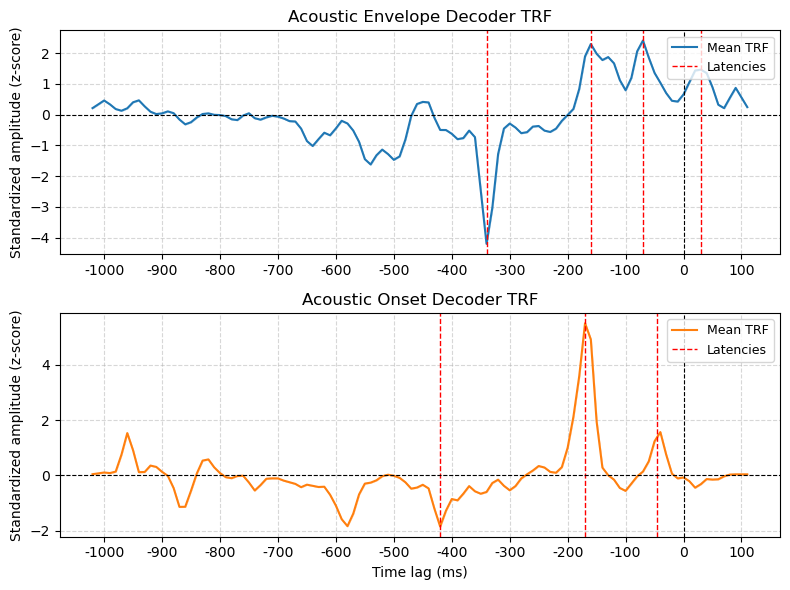

In [3]:
# ------------------------------------------------
# Load universal decoder TRFs
# ------------------------------------------------
decoder_trfs = {
    'log': eelbrain.load.unpickle(TRF_DIR / 'decoder-universal-trf-envelope_log.pickle'),
    'onset': eelbrain.load.unpickle(TRF_DIR / 'decoder-universal-trf-envelope_onset.pickle')
}

# ------------------------------------------------
# DEFINE LATENCIES (in seconds) PER MODEL
# ------------------------------------------------
latencies_dict = {
    'log':   [-0.070, -0.160, -0.340, 0.030],   # Envelope TRF latencies
    'onset': [-0.045, -0.170, -0.420]           # Onset TRF latencies
}

# ------------------------------------------------
# Prepare figure
# ------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

colors = {'log': 'tab:blue', 'onset': 'tab:orange'}

# ------------------------------------------------
# Plot loop
# ------------------------------------------------
for i, model in enumerate(['log', 'onset']):
    trf = decoder_trfs[model]

    # Average predictors if present
    if 'predictor' in trf.dims:
        trf_plot = trf.mean('predictor')
        trf_std = trf.std('predictor')
        if hasattr(trf_std, '__array__'):
            trf_std = np.array(trf_std)
    else:
        trf_plot = trf
        trf_std = np.zeros_like(trf_plot.x)

    # ----------------------------------------
    # Convert time to milliseconds
    # ----------------------------------------
    time_ms = np.array(trf_plot.time) * 1000  # <- FIXED

    # ----------------------------------------
    # Standardize
    # ----------------------------------------
    y = (trf_plot.x - np.mean(trf_plot.x)) / np.std(trf_plot.x)
    y_std = trf_std / np.std(trf_plot.x)

    # ----------------------------------------
    # Plot mean TRF
    # ----------------------------------------
    axes[i].plot(time_ms, y, color=colors[model], label='Mean TRF')

    # ----------------------------------------
    # Shaded ±1 SD
    # ----------------------------------------
    axes[i].fill_between(
        time_ms,
        y - y_std,
        y + y_std,
        color=colors[model],
        alpha=0.2
    )

    # ----------------------------------------
    # Vertical latency lines (MODEL-SPECIFIC)
    # ----------------------------------------
    latencies = latencies_dict[model]

    for j, t in enumerate(latencies):
        if j == 0:
            axes[i].axvline(t * 1000, color='red', linestyle='--', linewidth=1, label='Latencies')
        else:
            axes[i].axvline(t * 1000, color='red', linestyle='--', linewidth=1)

    # ----------------------------------------
    # Formatting
    # ----------------------------------------
    type_model = 'Acoustic Envelope' if model == 'log' else 'Acoustic Onset'

    axes[i].set_title(type_model + ' Decoder TRF')
    axes[i].set_ylabel('Standardized amplitude (z-score)')
    axes[i].axhline(0, linestyle='--', color='black', linewidth=0.8)
    axes[i].axvline(0, linestyle='--', color='black', linewidth=0.8)
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].legend(loc='upper right', fontsize=9)

    # Force x-axis ticks for both plots
    axes[i].xaxis.set_major_locator(MultipleLocator(100))  # every 100 ms
    axes[i].xaxis.set_major_formatter(FormatStrFormatter('%d'))
    axes[i].tick_params(axis='x', labelbottom=True)

# Shared x-axis label
axes[-1].set_xlabel('Time lag (ms)')

plt.tight_layout()
plt.show()



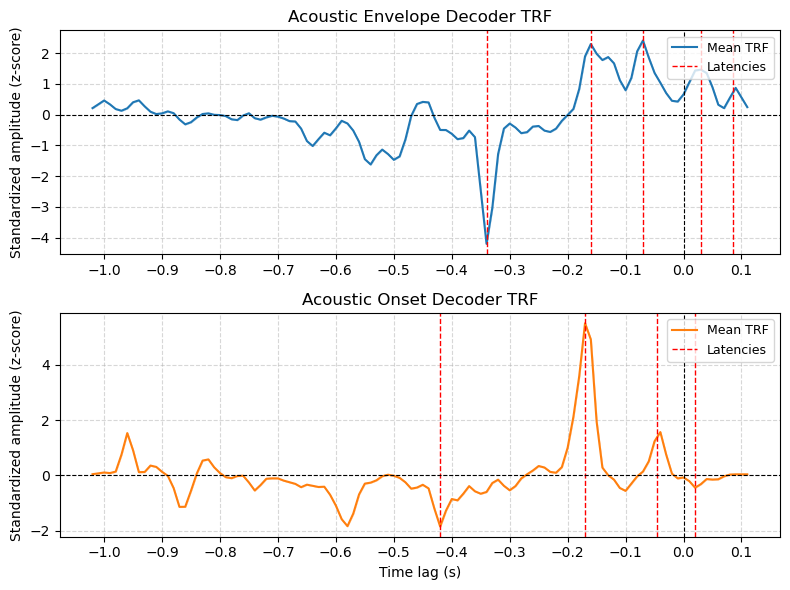

In [2]:
# ------------------------------------------------
# Load universal decoder TRFs
# ------------------------------------------------
decoder_trfs = {
    'log': eelbrain.load.unpickle(TRF_DIR / 'decoder-universal-trf-envelope_log.pickle'),
    'onset': eelbrain.load.unpickle(TRF_DIR / 'decoder-universal-trf-envelope_onset.pickle')
}

# ------------------------------------------------
# DEFINE LATENCIES (in seconds) PER MODEL
# ------------------------------------------------
latencies_dict = {
    'log':   [-0.070, -0.160, -0.340, 0.030, 0.085],   # Envelope TRF latencies
    'onset': [-0.045, -0.170, -0.420, 0.020]    # Onset TRF latencies
}

# ------------------------------------------------
# Prepare figure
# ------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

colors = {'log': 'tab:blue', 'onset': 'tab:orange'}

# ------------------------------------------------
# Plot loop
# ------------------------------------------------
for i, model in enumerate(['log', 'onset']):
    trf = decoder_trfs[model]

    # Average predictors if present
    if 'predictor' in trf.dims:
        trf_plot = trf.mean('predictor')
        trf_std = trf.std('predictor')
        if hasattr(trf_std, 'x'):
            trf_std = trf_std.x
    else:
        trf_plot = trf
        trf_std = np.zeros_like(trf_plot.x)

    # ----------------------------------------
    # Standardize
    # ----------------------------------------
    y = (trf_plot.x - np.mean(trf_plot.x)) / np.std(trf_plot.x)
    y_std = trf_std / np.std(trf_plot.x)

    # ----------------------------------------
    # Plot mean TRF
    # ----------------------------------------
    axes[i].plot(trf_plot.time, y, color=colors[model], label='Mean TRF')

    # ----------------------------------------
    # Shaded ±1 SD
    # ----------------------------------------
    axes[i].fill_between(
        trf_plot.time,
        y - y_std,
        y + y_std,
        color=colors[model],
        alpha=0.2
    )

    # ----------------------------------------
    # Vertical latency lines (MODEL-SPECIFIC)
    # ----------------------------------------
    latencies = latencies_dict[model]

    for j, t in enumerate(latencies):
        if j == 0:
            axes[i].axvline(t, color='red', linestyle='--', linewidth=1, label='Latencies')
        else:
            axes[i].axvline(t, color='red', linestyle='--', linewidth=1)

    # ----------------------------------------
    # Formatting
    # ----------------------------------------
    type_model = 'Acoustic Envelope' if model == 'log' else 'Acoustic Onset'

    for ax in axes:
        ax.xaxis.set_major_locator(MultipleLocator(0.1))

    axes[i].set_title(type_model + ' Decoder TRF')
    axes[i].set_ylabel('Standardized amplitude (z-score)')
    axes[i].axhline(0, linestyle='--', color='black', linewidth=0.8)
    axes[i].axvline(0, linestyle='--', color='black', linewidth=0.8)
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].legend(loc='upper right', fontsize=9)

    axes[i].tick_params(axis='x', labelbottom=True)


# Shared x-axis
axes[-1].set_xlabel('Time lag (s)')

plt.tight_layout()
plt.show()



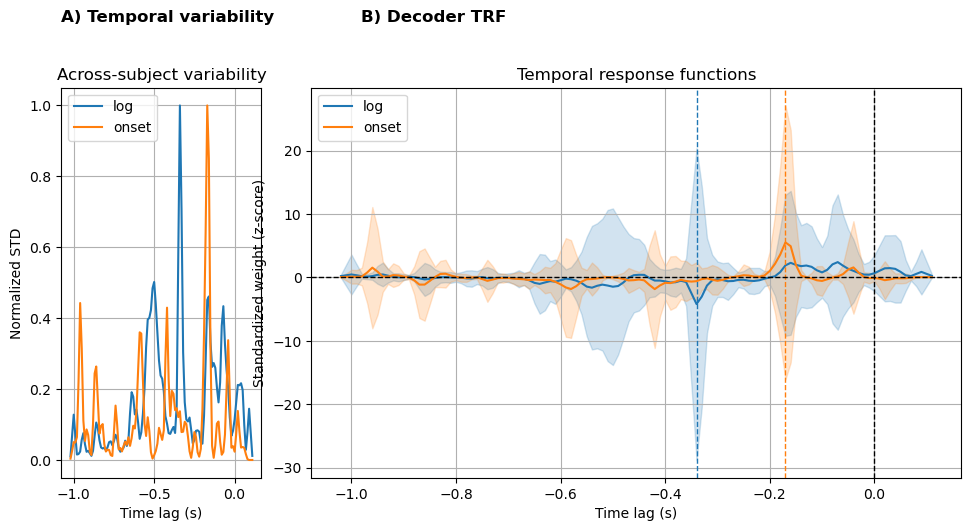

In [9]:
import matplotlib.pyplot as plt
import eelbrain
import numpy as np

# ------------------------------------------------
# Load universal decoder TRFs
# ------------------------------------------------
decoder_trfs = {
    'log': eelbrain.load.unpickle(TRF_DIR / 'decoder-universal-trf-envelope_log.pickle'),
    'onset': eelbrain.load.unpickle(TRF_DIR / 'decoder-universal-trf-envelope_onset.pickle')
}

# ------------------------------------------------
# Load subject-level TRFs (for variability)
# ------------------------------------------------
all_subjects_decoder = {
    'log': [],
    'onset': []
}

for model in models:
    type_model = 'log' if model == 'envelope_log' else 'onset'
    for subject in SUBJECTS:
        trf = eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} decoder-{model}.pickle').h_scaled
        all_subjects_decoder[type_model].append(trf[0])

# ------------------------------------------------
# Compute mean + std across subjects
# ------------------------------------------------
mean_trfs = {}
std_trfs = {}

for model in ['log', 'onset']:
    stacked = eelbrain.combine(all_subjects_decoder[model])

    # Average predictors if needed
    if 'predictor' in stacked.dims:
        stacked = stacked.mean('predictor')

    mean_trfs[model] = stacked.mean('case')
    std_trfs[model] = stacked.std('case')

# ------------------------------------------------
# FIGURE SETUP (mirrors encoder style)
# ------------------------------------------------
fig = plt.figure(figsize=(10, 6))

# Panel labels
fig.text(0.05, 0.96, 'A) Temporal variability', fontsize=12, fontweight='bold')
fig.text(0.35, 0.96, 'B) Decoder TRF', fontsize=12, fontweight='bold')

# Layout
left_col = 0.05
right_col = 0.30
row_height = 0.65
width_var = 0.20
width_trf = 0.65

# ------------------------------------------------
# A) VARIABILITY OVER TIME
# ------------------------------------------------
ax_var = fig.add_axes([left_col, 0.20, width_var, row_height])

colors = {'log': 'tab:blue', 'onset': 'tab:orange'}

for model in ['log', 'onset']:
    trf_std = std_trfs[model]

    time = trf_std.time
    y = trf_std.x

    # Normalize for visual comparison
    y = y / np.max(y)

    ax_var.plot(time, y, label=model, color=colors[model])

ax_var.set_title('Across-subject variability')
ax_var.set_xlabel('Time lag (s)')
ax_var.set_ylabel('Normalized STD')
ax_var.legend()
ax_var.grid(True)

# ------------------------------------------------
# B) DECODER TRF
# ------------------------------------------------
ax_trf = fig.add_axes([right_col, 0.20, width_trf, row_height])

for model in ['log', 'onset']:
    trf_mean = mean_trfs[model]
    trf_std = std_trfs[model]

    time = trf_mean.time
    y = trf_mean.x
    y_std = trf_std.x

    # ----------------------------------------
    # Z-score normalization
    # ----------------------------------------
    y = (y - np.mean(y)) / np.std(y)
    y_std = y_std / np.std(trf_mean.x)

    # ----------------------------------------
    # Plot mean
    # ----------------------------------------
    ax_trf.plot(time, y, label=model, color=colors[model])

    # ----------------------------------------
    # Shaded variability
    # ----------------------------------------
    ax_trf.fill_between(time, y - y_std, y + y_std,
                        color=colors[model], alpha=0.2)

    # ----------------------------------------
    # Peak latency
    # ----------------------------------------
    peak_idx = np.argmax(np.abs(y))
    peak_time = time[peak_idx]

    ax_trf.axvline(peak_time,
                   color=colors[model],
                   linestyle='--',
                   linewidth=1)

# Formatting
ax_trf.set_title('Temporal response functions')
ax_trf.set_xlabel('Time lag (s)')
ax_trf.set_ylabel('Standardized weight (z-score)')
ax_trf.axhline(0, linestyle='--', linewidth=1, color='black')
ax_trf.axvline(0, linestyle='--', linewidth=1, color='black')
ax_trf.legend()
ax_trf.grid(True)

plt.show()


NameError: name 'log_scores' is not defined

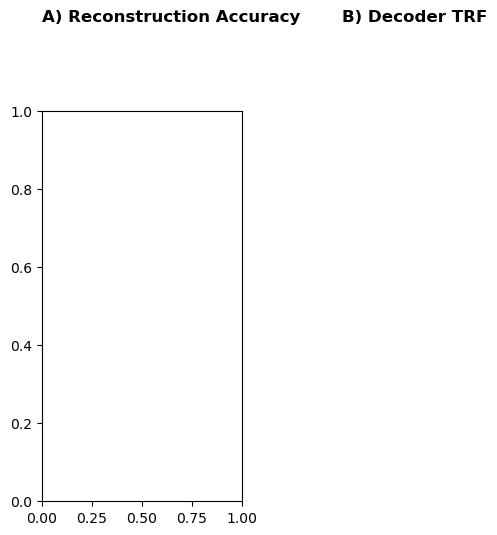

In [6]:
import matplotlib.pyplot as plt
import eelbrain
import numpy as np

# ------------------------------------------------
# Load universal decoder TRFs
# ------------------------------------------------
decoder_trfs = {
    'log': eelbrain.load.unpickle(TRF_DIR / 'decoder-universal-trf-envelope_log.pickle'),
    'onset': eelbrain.load.unpickle(TRF_DIR / 'decoder-universal-trf-envelope_onset.pickle')
}

# ------------------------------------------------
# Subject-level TRFs (for variability)
# ------------------------------------------------
all_subjects_decoder = {
    'log': [],
    'onset': []
}

for model in models:
    type_model = 'log' if model == 'envelope_log' else 'onset'
    for subject in SUBJECTS:
        trf = eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} decoder-{model}.pickle').h_scaled
        all_subjects_decoder[type_model].append(trf[0])

# ------------------------------------------------
# Compute mean + std across subjects
# ------------------------------------------------
mean_trfs = {}
std_trfs = {}

for model in ['log', 'onset']:
    stacked = eelbrain.combine(all_subjects_decoder[model])

    # Average predictors if needed
    if 'predictor' in stacked.dims:
        stacked = stacked.mean('predictor')

    mean_trfs[model] = stacked.mean('case')
    std_trfs[model] = stacked.std('case')

# ------------------------------------------------
# FIGURE
# ------------------------------------------------
fig = plt.figure(figsize=(10, 6))

# Panel labels
fig.text(0.05, 0.95, 'A) Reconstruction Accuracy', fontsize=12, fontweight='bold')
fig.text(0.35, 0.95, 'B) Decoder TRF', fontsize=12, fontweight='bold')

# ------------------------------------------------
# A) PERFORMANCE (boxplot)
# ------------------------------------------------
ax_perf = fig.add_axes([0.05, 0.15, 0.20, 0.65])

# Replace these with your actual scores
# (you said you have them)
data = [log_scores, onset_scores]

ax_perf.boxplot(data, labels=['Envelope', 'Onset'])
ax_perf.set_ylabel('Reconstruction accuracy (r)')
ax_perf.set_title('Model performance')
ax_perf.grid(True)

# ------------------------------------------------
# B) TRF PLOT
# ------------------------------------------------
ax_trf = fig.add_axes([0.30, 0.15, 0.65, 0.65])

colors = {'log': 'tab:blue', 'onset': 'tab:orange'}

for model in ['log', 'onset']:
    trf_mean = mean_trfs[model]
    trf_std = std_trfs[model]

    time = trf_mean.time
    y = trf_mean.x
    y_std = trf_std.x

    # ----------------------------------------
    # Z-score normalization
    # ----------------------------------------
    y = (y - np.mean(y)) / np.std(y)
    y_std = y_std / np.std(trf_mean.x)

    # ----------------------------------------
    # Plot mean
    # ----------------------------------------
    ax_trf.plot(time, y, label=model, color=colors[model])

    # ----------------------------------------
    # Plot variability (shaded)
    # ----------------------------------------
    ax_trf.fill_between(time, y - y_std, y + y_std,
                        color=colors[model], alpha=0.2)

    # ----------------------------------------
    # Peak latency
    # ----------------------------------------
    peak_idx = np.argmax(np.abs(y))
    peak_time = time[peak_idx]

    ax_trf.axvline(peak_time,
                   color=colors[model],
                   linestyle='--',
                   linewidth=1)

# Formatting
ax_trf.set_xlabel('Time lag (s)')
ax_trf.set_ylabel('Standardized weight (z-score)')
ax_trf.set_title('Temporal response functions')
ax_trf.axhline(0, linestyle='--', linewidth=1, color='black')
ax_trf.axvline(0, linestyle='--', linewidth=1, color='black')
ax_trf.legend()
ax_trf.grid(True)

plt.show()
